100%|██████████| 9.91M/9.91M [00:00<00:00, 60.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.02MB/s]


Iniciando el entrenamiento (Dimensión Latente 2)...
Época [1/15], Pérdida: 0.2071
Época [2/15], Pérdida: 0.1948
Época [3/15], Pérdida: 0.1917
Época [4/15], Pérdida: 0.1898
Época [5/15], Pérdida: 0.1887
Época [6/15], Pérdida: 0.1877
Época [7/15], Pérdida: 0.1869
Época [8/15], Pérdida: 0.1866
Época [9/15], Pérdida: 0.1862
Época [10/15], Pérdida: 0.1858
Época [11/15], Pérdida: 0.1857
Época [12/15], Pérdida: 0.1853
Época [13/15], Pérdida: 0.1852
Época [14/15], Pérdida: 0.1851
Época [15/15], Pérdida: 0.1848


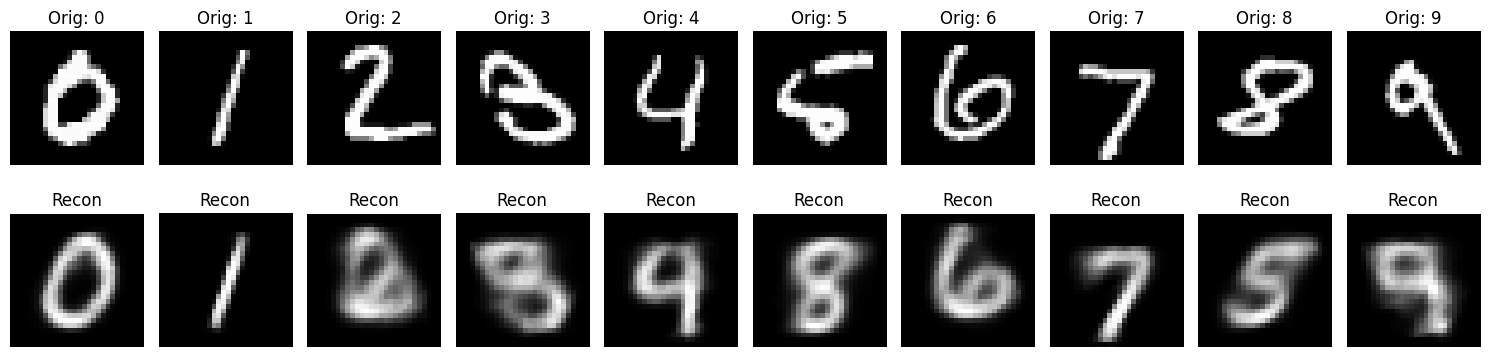

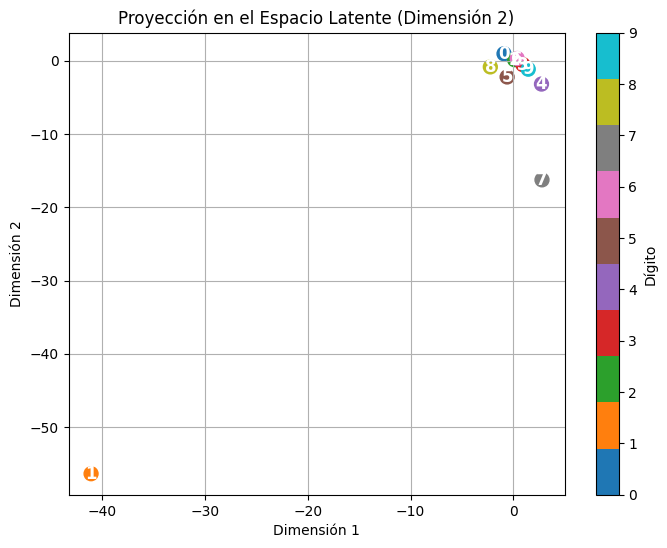

Creando animación GIF...

¡GIF generado exitosamente! Guardado como 'morphing_mnist_2.gif'

--- INICIANDO PRUEBA DE SEPARABILIDAD LINEAL (ESPACIO 2D) ---
Entrenando clasificador lineal (Sonda Lineal)...
Entrenamiento finalizado.
--> PRECISIÓN DEL CLASIFICADOR LINEAL: 44.33%


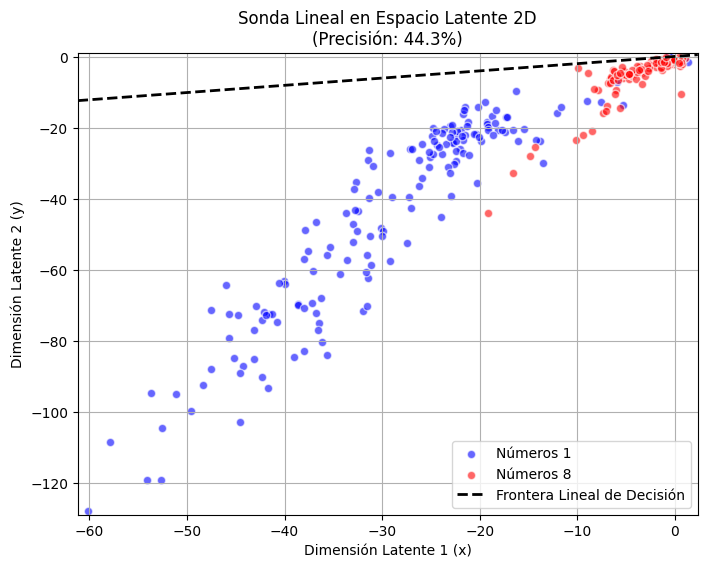

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. CARGA Y PREPROCESADO DE DATOS (Se mantiene igual)
# Convertimos a tensor (normaliza los píxeles al rango [0,1]) y aplanamos a dimensión 784
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

# Descargamos y cargamos el dataset MNIST
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Usamos DataLoader para procesar en lotes durante el entrenamiento
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1, shuffle=False)

# 2. ARQUITECTURA DEL AE (CAMBIO A DIMENSIÓN 2)
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Codificador: 784 → 128 → 2 (ANTES ERA 16)
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # <-- CAMBIO A 2
        )
        # Decodificador: 2 → 128 → 784 (ANTES ERA 16)
        self.decoder = nn.Sequential(
            nn.Linear(2, 128), # <-- CAMBIO A 2
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid() # Activación sigmoide final para salidas entre 0 y 1
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder()

# 3. PÉRDIDA Y OPTIMIZACIÓN
# Entropía cruzada binaria (BCE) ya que las entradas están normalizadas entre 0 y 1
criterion = nn.BCELoss()

# Descenso del gradiente estocástico (SGD) con una tasa de aprendizaje 0.1
# NOTA: Al comprimir tanto (a 2D), a SGD le cuesta mucho más converger.
# Si el resultado es muy malo, puedes subir el lr a 0.5 o usar optim.Adam(model.parameters(), lr=0.01)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. ENTRENAMIENTO
epocas = 15
print("Iniciando el entrenamiento (Dimensión Latente 2)...")
for epoch in range(epocas):
    train_loss = 0.0
    for images, _ in train_loader:
        # Forward pass (pasar las imágenes por el AE)
        outputs = model(images)
        loss = criterion(outputs, images) # Comparar salida con la imagen original

        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    print(f'Época [{epoch+1}/{epocas}], Pérdida: {train_loss:.4f}')


# 5. VISUALIZACIÓN DE RESULTADOS (Adaptada a 2D)
model.eval()
ejemplos_digitos = {}

# Recogemos un ejemplo de cada dígito
for images, labels in test_loader:
    label = labels.item()
    if label not in ejemplos_digitos:
        ejemplos_digitos[label] = images
    if len(ejemplos_digitos) == 10:
        break

# Ordenamos los dígitos del 0 al 9
imagenes_originales = [ejemplos_digitos[i] for i in range(10)]
imagenes_originales_tensor = torch.cat(imagenes_originales)

# Generamos las codificaciones (espacio latente) y las reconstrucciones
with torch.no_grad():
    # 1. Pasamos la imagen solo por el codificador para obtener el vector de tamaño 2
    codificaciones = model.encoder(imagenes_originales_tensor)
    # 2. Pasamos esa codificación por el decodificador para la imagen final
    reconstrucciones = model.decoder(codificaciones)

# Mostramos las imágenes originales y las reconstruidas
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(15, 4)) # Ahora solo 2 filas
for i in range(10):
    # Imágenes originales
    ax = axes[0, i]
    ax.imshow(imagenes_originales_tensor[i].view(28, 28).numpy(), cmap='gray')
    ax.set_title(f'Orig: {i}')
    ax.axis('off')

    # Reconstrucciones
    ax = axes[1, i]
    ax.imshow(reconstrucciones[i].view(28, 28).numpy(), cmap='gray')
    ax.set_title('Recon')
    ax.axis('off')

plt.tight_layout()
plt.show()

# EXTRA: VISUALIZACIÓN DEL ESPACIO LATENTE 2D
# Como ahora la codificación es un punto (x, y), podemos graficar dónde cae cada número
plt.figure(figsize=(8, 6))
coord_x = codificaciones[:, 0].numpy()
coord_y = codificaciones[:, 1].numpy()

plt.scatter(coord_x, coord_y, c=range(10), cmap='tab10', s=100)
for i in range(10):
    plt.annotate(str(i), (coord_x[i], coord_y[i]), fontsize=12, fontweight='bold', ha='center', va='center', color='white')

plt.title("Proyección en el Espacio Latente (Dimensión 2)")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.colorbar(ticks=range(10), label="Dígito")
plt.grid(True)
plt.show()

# --- 6. GENERACIÓN DEL GIF (T y PORCENTAJE EN CADA FRAME) ---
import matplotlib.animation as animation
print("Creando animación GIF...")

t_originales = imagenes_originales_tensor.cpu().detach()
t_reconstruidas = reconstrucciones.cpu().detach()

frames_pausa_inicio = 10
frames_transicion = 40
frames_pausa_fin = 50  # Pausa larga al final
total_frames = frames_pausa_inicio + frames_transicion + frames_pausa_fin

fig, axes_grid = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
axes = axes_grid.flatten()
plt.subplots_adjust(wspace=0.1, hspace=0.3, top=0.85) # Margen superior para el título

plots_imagenes = []

# Inicializamos las imágenes
for i in range(10):
    img_obj = axes[i].imshow(t_originales[i].view(28, 28).numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Dígito {i}")
    axes[i].axis('off')
    plots_imagenes.append(img_obj)

# Esta función se ejecuta en cada uno de los frames
def update_animation(frame_idx):
    # 1. Calcular 't'
    if frame_idx < frames_pausa_inicio:
        t = 0.0
    elif frame_idx < frames_pausa_inicio + frames_transicion:
        step_actual = frame_idx - frames_pausa_inicio
        t = step_actual / (frames_transicion - 1)
    else:
        t = 1.0

    # --- ACTUALIZACIÓN DEL TÍTULO EN CADA FRAME ---
    porcentaje = int(t * 100)
    fig.suptitle(f'Transformación Lineal | t = {t:.2f} ({porcentaje}%)',
                 fontsize=18, fontweight='bold', color='darkred')

    # 2. Aplicar interpolación a las imágenes
    for i in range(10):
        img_orig = t_originales[i].view(28, 28)
        img_recon = t_reconstruidas[i].view(28, 28)

        # Ecuación lineal: (1 - t)*A + t*B
        img_interpolada = (1 - t) * img_orig + t * img_recon
        plots_imagenes[i].set_data(img_interpolada.numpy())

    return plots_imagenes

ani = animation.FuncAnimation(
    fig,
    update_animation,
    frames=total_frames,
    interval=50,
    blit=False # <-- IMPORTANTE: blit=False asegura que el título cambie en el GIF
)

nombre_archivo = 'morphing_mnist_2.gif'
ani.save(nombre_archivo, writer='pillow', fps=25)

print(f"\n¡GIF generado exitosamente! Guardado como '{nombre_archivo}'")
plt.close(fig)





import torch.nn.functional as F
import numpy as np

print("\n--- INICIANDO PRUEBA DE SEPARABILIDAD LINEAL (ESPACIO 2D) ---")

# 1. RECOLECTAR 300 IMÁGENES DE '1' y '8'
imagenes_1_8 = []
etiquetas_true = []

for img, label in train_dataset:
    if label == 1 or label == 8:
        imagenes_1_8.append(img)
        # 0 para el número 1, 1 para el número 8
        etiquetas_true.append(0 if label == 1 else 1)

    if len(imagenes_1_8) == 300:
        break

x_imagenes = torch.stack(imagenes_1_8)
y_clases = torch.tensor(etiquetas_true)

# Convertimos a One-Hot: Clase 0 -> [1, 0], Clase 1 -> [0, 1]
y_onehot = F.one_hot(y_clases, num_classes=2).float()

# 2. OBTENER LOS PUNTOS EN EL ESPACIO LATENTE (2 DIMENSIONES)
model.eval()
with torch.no_grad():
    z_puntos = model.encoder(x_imagenes) # Vector de tamaño [300, 2]

# 3. CREAR EL CLASIFICADOR LINEAL CON SOFTMAX
class ClasificadorLineal(nn.Module):
    def __init__(self):
        super(ClasificadorLineal, self).__init__()
        # Entrada: 2 (x, y en el espacio latente). Salida: 2 (a, b para el softmax)
        self.lineal = nn.Linear(2, 2)

    def forward(self, x):
        out_lineal = self.lineal(x)
        return F.softmax(out_lineal, dim=1)

clasificador = ClasificadorLineal()

# 4. ENTRENAMIENTO DEL CLASIFICADOR (usando la pérdida cuadrática que pediste)
criterion_mse = nn.MSELoss()
optimizer_clf = optim.Adam(clasificador.parameters(), lr=0.1)

epocas_clf = 100
print("Entrenando clasificador lineal (Sonda Lineal)...")
for epoch in range(epocas_clf):
    optimizer_clf.zero_grad()

    # y^ = softmax(w*x + b)
    y_pred = clasificador(z_puntos)

    # L = 1/2 * (y - y^)^2
    loss = criterion_mse(y_pred, y_onehot)

    loss.backward()
    optimizer_clf.step()

# --- EVALUAR PRECISIÓN ---
with torch.no_grad():
    y_pred_final = clasificador(z_puntos)
    predicciones = torch.argmax(y_pred_final, dim=1)
    correctos = (predicciones == y_clases).sum().item()
    precision = (correctos / 300.0) * 100

print("Entrenamiento finalizado.")
print(f"--> PRECISIÓN DEL CLASIFICADOR LINEAL: {precision:.2f}%")

# 5. VISUALIZAR LA LÍNEA DE DECISIÓN EN 2D
plt.figure(figsize=(8, 6))

z_np = z_puntos.numpy()
clases_np = y_clases.numpy()

# Pintar nubes de puntos
plt.scatter(z_np[clases_np == 0, 0], z_np[clases_np == 0, 1], c='blue', label='Números 1', alpha=0.6, edgecolors='w')
plt.scatter(z_np[clases_np == 1, 0], z_np[clases_np == 1, 1], c='red', label='Números 8', alpha=0.6, edgecolors='w')

# Dibujar la frontera lineal donde P(Clase 0) == P(Clase 1)
pesos = clasificador.lineal.weight.detach().numpy()
sesgos = clasificador.lineal.bias.detach().numpy()

w_diff = pesos[0] - pesos[1]
b_diff = sesgos[0] - sesgos[1]

# Límites del gráfico
x_min, x_max = z_np[:, 0].min() - 1, z_np[:, 0].max() + 1
x_vals = np.array([x_min, x_max])

# Trazar la línea si no es completamente vertical
if w_diff[1] != 0:
    y_vals = (-w_diff[0] * x_vals - b_diff) / w_diff[1]
    plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Frontera Lineal de Decisión')

# Ajustar límites visuales
plt.xlim(x_min, x_max)
plt.ylim(z_np[:, 1].min() - 1, z_np[:, 1].max() + 1)

plt.title(f"Sonda Lineal en Espacio Latente 2D\n(Precisión: {precision:.1f}%)")
plt.xlabel("Dimensión Latente 1 (x)")
plt.ylabel("Dimensión Latente 2 (y)")
plt.legend()
plt.grid(True)
plt.show()